# 1. Importação de Bibliotecas e carregamento de dados

## 1.1. Bibliotecas

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import openpyxl
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

In [10]:
file_path = 'data/raw/BASE_PEDE_2024-DATATHON.xlsx'
xls = pd.ExcelFile(file_path)

# Listar as abas disponíveis
print(xls.sheet_names)

# Carregar cada aba em um DataFrame
df1 = pd.read_excel(xls, 'PEDE2022')
df2 = pd.read_excel(xls, 'PEDE2023')
df3 = pd.read_excel(xls, 'PEDE2024')

# Incluir coluna de ano em cada DataFrame
df1['Ano'] = 2022
df2['Ano'] = 2023
df3['Ano'] = 2024

['PEDE2022', 'PEDE2023', 'PEDE2024']


In [11]:
#verificar quantidade de linhas e colunas de cada DataFrame
print(df1.shape)
print(df2.shape)
print(df3.shape)

(860, 43)
(1014, 49)
(1156, 51)


In [12]:
# verificar dados distintos coluna Gênero
print(df1['Gênero'].unique())
print(df2['Gênero'].unique())
print(df3['Gênero'].unique())
    

<StringArray>
['Menina', 'Menino']
Length: 2, dtype: str
<StringArray>
['Feminino', 'Masculino']
Length: 2, dtype: str
<StringArray>
['Masculino', 'Feminino']
Length: 2, dtype: str


In [13]:
# Substituição/Padronização de gênero entre bases
df1['Gênero'] = df1['Gênero'].replace({'Menino': 'Masculino', 'Menina': 'Feminino'})
# Verificar os valores únicos após a padronização
print(df1['Gênero'].unique())

<StringArray>
['Feminino', 'Masculino']
Length: 2, dtype: str


In [14]:
#Padronização de labels das colunas
def padronizar_colunas(df):
    df.columns = df.columns.str.strip().str.upper()
    return df

df1 = padronizar_colunas(df1)
df2 = padronizar_colunas(df2)
df3 = padronizar_colunas(df3)

# mapeamento de labels
mapa_colunas = {
    'GÊNERO': 'GENERO',
    'NOME': 'NOME_ANONIMIZADO',
    'NOME ANONIMIZADO': 'NOME_ANONIMIZADO',
    'MATEM': 'MAT',
    'PORTUG': 'POR',
    'INGLÊS': 'ING'
    
}

df1 = df1.rename(columns=mapa_colunas)
df2 = df2.rename(columns=mapa_colunas)
df3 = df3.rename(columns=mapa_colunas)


In [15]:
# Padronização dos dados da feature FASE
def padronizar_fase(df):
    mapa_fase = {
        'ALFA': 0, 'FASE 1': 1, 'FASE 2': 2, 'FASE 3': 3, 'FASE 4': 4, 'FASE 5': 5,
        'FASE 6': 6, 'FASE 7': 7, 'FASE 8': 8,
        '1A': 1, '1B': 1, '1C': 1, '1D': 1, '1E': 1, '1G': 1, '1H': 1,
        '1J': 1, '1K': 1, '1L': 1, '1M': 1, '1N': 1, '1P': 1, '1R': 1,
        '2A': 2, '2B': 2, '2C': 2, '2D': 2, '2G': 2, '2H': 2, '2I': 2,
        '2K': 2, '2L': 2, '2M': 2, '2N': 2, '2P': 2, '2R': 2, '2U': 2,
        '3A': 3, '3B': 3, '3C': 3, '3D': 3, '3F': 3, '3G': 3, '3H': 3,
        '3I': 3, '3K': 3, '3L': 3, '3M': 3, '3N': 3, '3P': 3, '3R': 3, '3U': 3,
        '4A': 4, '4B': 4, '4C': 4, '4F': 4, '4H': 4, '4L': 4, '4M': 4, '4N': 4,
        '4R': 4, '5A': 5, '5B': 5, '5C': 5, '5D': 5, '5F': 5, '5G': 5, '5L': 5,
        '5M': 5, '5N': 5, '6A': 6, '6L': 6, '7A': 7, '7E': 7,
        '8A': 8, '8B': 8, '8D': 8, '8E': 8, '8F': 8,
        7: 7, 6: 6, 5: 5, 4: 4, 3: 3, 2: 2, 1: 1, 0: 0, 9: 9
    }
    df['FASE'] = df['FASE'].map(mapa_fase)
    return df
df1 = padronizar_fase(df1)
df2 = padronizar_fase(df2)
df3 = padronizar_fase(df3)

In [16]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1156 non-null   str           
 1   FASE                   1156 non-null   int64         
 2   INDE 2024              1092 non-null   object        
 3   PEDRA 2024             1092 non-null   str           
 4   TURMA                  1156 non-null   object        
 5   NOME_ANONIMIZADO       1156 non-null   str           
 6   DATA DE NASC           1156 non-null   datetime64[us]
 7   IDADE                  1156 non-null   int64         
 8   GENERO                 1156 non-null   str           
 9   ANO INGRESSO           1156 non-null   int64         
 10  INSTITUIÇÃO DE ENSINO  1155 non-null   str           
 11  PEDRA 20               191 non-null    str           
 12  PEDRA 21               264 non-null    str           
 13  PEDRA 22      

In [17]:
# Criação de coluna INDE_ATUAL para unificar o indicador de desempenho posteriormente
df1['INDE_ATUAL'] = df1['INDE 22']
df2['INDE_ATUAL'] = df2['INDE 2023']
df3['INDE_ATUAL'] = df3['INDE 2024']


1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

In [18]:
# Classificação do IAN
def classificar_ian(valor):
    if valor == 2.5:
        return 'Severa'
    elif valor == 5.0:
        return 'Moderada'
    elif valor == 10.0:
        return 'Adequado'
    else:
        return 'Outro'

df_pergunta1 = pd.concat([df1[['GENERO', 'IAN', 'ANO']], df2[['GENERO', 'IAN', 'ANO']], df3[['GENERO', 'IAN', 'ANO']]], ignore_index=True)
df_pergunta1['CATEGORIA_IAN'] = df_pergunta1['IAN'].apply(classificar_ian)



In [19]:
#Verificar valores nulos
df_pergunta1.isnull().sum()

GENERO           0
IAN              0
ANO              0
CATEGORIA_IAN    0
dtype: int64

In [20]:
# Distribuição geral
contagem = df_pergunta1['CATEGORIA_IAN'].value_counts()
print("Distribuição geral:")
print(contagem)

# Distribuição geral em percentual
percentual = df_pergunta1['CATEGORIA_IAN'].value_counts(normalize=True) * 100
print("\nPercentual geral:")
print(percentual)

# Distribuição por ANO
dist_ano = df_pergunta1.groupby(['ANO', 'CATEGORIA_IAN']).size().unstack(fill_value=0)
print("\nDistribuição por ano (absoluto):")
print(dist_ano)

# Percentual por ano
dist_ano_pct = dist_ano.div(dist_ano.sum(axis=1), axis=0) * 100
print("\nDistribuição por ano (%):")
print(dist_ano_pct)

# Evolução do IAN
media_ano = df_pergunta1.groupby('ANO')['IAN'].mean().reset_index()
print("\nMédia de IAN por ano:")
print(media_ano)


media_genero = df_pergunta1.groupby(['ANO', 'GENERO'])['IAN'].mean().reset_index()
print("\nMédia por ano e gênero:")
print(media_genero)

#media feminino e masculino
media_feminino = media_genero[media_genero['GENERO'] == 'Feminino']
media_masculino = media_genero[media_genero['GENERO'] == 'Masculino']

Distribuição geral:
CATEGORIA_IAN
Moderada    1642
Adequado    1343
Severa        45
Name: count, dtype: int64

Percentual geral:
CATEGORIA_IAN
Moderada    54.191419
Adequado    44.323432
Severa       1.485149
Name: proportion, dtype: float64

Distribuição por ano (absoluto):
CATEGORIA_IAN  Adequado  Moderada  Severa
ANO                                      
2022                259       573      28
2023                462       538      14
2024                622       531       3

Distribuição por ano (%):
CATEGORIA_IAN   Adequado   Moderada    Severa
ANO                                          
2022           30.116279  66.627907  3.255814
2023           45.562130  53.057199  1.380671
2024           53.806228  45.934256  0.259516

Média de IAN por ano:
    ANO       IAN
0  2022  6.424419
1  2023  7.243590
2  2024  7.683824

Média por ano e gênero:
    ANO     GENERO       IAN
0  2022   Feminino  6.477024
1  2022  Masculino  6.364764
2  2023   Feminino  7.477106
3  2023  Masculino  

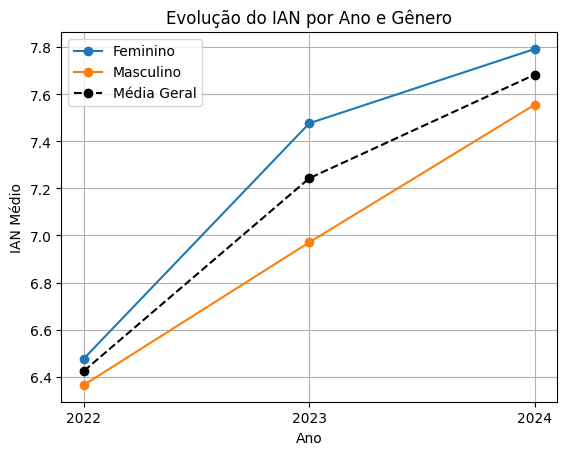

In [21]:
# Gráfico Evolução

plt.figure()

for genero in media_genero['GENERO'].dropna().unique():
    subset = media_genero[media_genero['GENERO'] == genero]
    plt.plot(subset['ANO'], subset['IAN'], marker='o', label=str(genero))
plt.plot(media_ano['ANO'], media_ano['IAN'], marker='o', label='Média Geral', linestyle='--', color='black')

plt.title('Evolução do IAN por Ano e Gênero')
plt.xlabel('Ano')
plt.ylabel('IAN Médio')
plt.xticks([2022, 2023, 2024])

plt.legend()
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

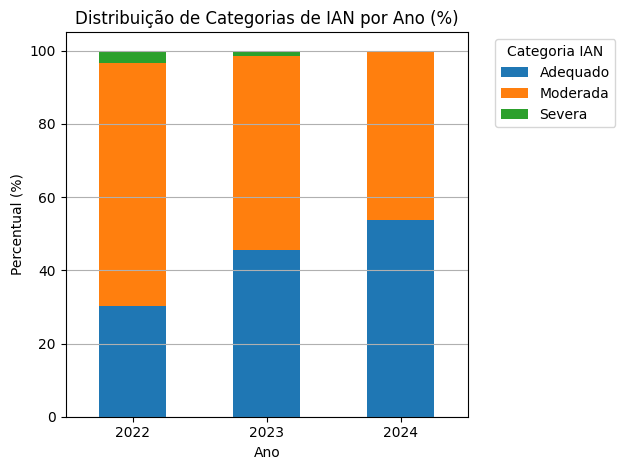

In [22]:
plt.figure()

dist_ano_pct.plot(kind='bar', stacked=True)

plt.title('Distribuição de Categorias de IAN por Ano (%)')
plt.xlabel('Ano')
plt.ylabel('Percentual (%)')

# Melhorar legenda
plt.legend(title='Categoria IAN', bbox_to_anchor=(1.05, 1), loc='upper left')

# Melhorar visual
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [23]:
# Separando dados necessários para análise da pergunta 2
features = ['GENERO', 'IAN', 'IDA', 'ANO', 'FASE']
#Criar df_pergunta2
df_pergunta2 = pd.concat([df1[features], df2[features], df3[features]], ignore_index=True)
df_pergunta2

,GENERO,IAN,IDA,ANO,FASE
0,Feminino,5.0,4.0,2022,7
1,Feminino,10.0,6.8,2022,7
2,Feminino,10.0,5.6,2022,7
3,Masculino,10.0,5.0,2022,7
4,Feminino,10.0,5.2,2022,7
...,...,...,...,...,...
3025,Masculino,10.0,NaN,2024,9
3026,Masculino,10.0,NaN,2024,9
3027,Feminino,10.0,NaN,2024,9
3028,Feminino,10.0,NaN,2024,9


In [24]:
# Verificando valores nulos
df_pergunta2.isnull().sum()


GENERO      0
IAN         0
IDA       178
ANO         0
FASE        0
dtype: int64

In [25]:
# Exclusão de linhas com valores nulos
df_pergunta2 = df_pergunta2.dropna()

In [26]:
# Média do IDA por ano
print("\nMédia do IDA por ano:")
media_ida_ano = df_pergunta2.groupby('ANO')['IDA'].mean().reset_index()
print(media_ida_ano)

# Média do IDA por ano e gênero
print("\nMédia do IDA por ano e gênero:")
media_ida_genero = df_pergunta2.groupby(['ANO', 'GENERO'])['IDA'].mean().reset_index()
print(media_ida_genero)

# Verificação de variação percentual do IDA ao longo dos anos
print("\nVariação percentual do IDA por ano:")
media_ida_ano['VARIACAO_%'] = media_ida_ano['IDA'].pct_change() * 100
print(media_ida_ano)


Média do IDA por ano:
    ANO       IDA
0  2022  6.092907
1  2023  6.663394
2  2024  6.351422

Média do IDA por ano e gênero:
    ANO     GENERO       IDA
0  2022   Feminino  6.178337
1  2022  Masculino  5.996030
2  2023   Feminino  6.654747
3  2023  Masculino  6.673077
4  2024   Feminino  6.347752
5  2024  Masculino  6.355751

Variação percentual do IDA por ano:
    ANO       IDA  VARIACAO_%
0  2022  6.092907         NaN
1  2023  6.663394    9.363131
2  2024  6.351422   -4.681879


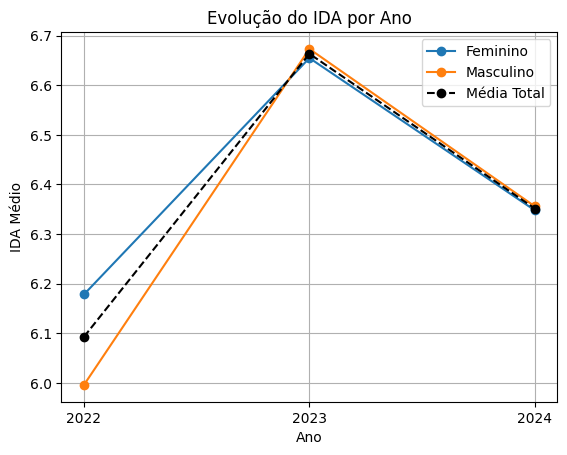

In [27]:
plt.figure()

for genero in media_ida_genero['GENERO'].dropna().unique():
    subset = media_ida_genero[media_ida_genero['GENERO'] == genero]
    plt.plot(subset['ANO'], subset['IDA'], marker='o', label=str(genero))
plt.plot(media_ida_ano['ANO'], media_ida_ano['IDA'], marker='o', label='Média Total', linestyle='--', color='black')

plt.title('Evolução do IDA por Ano')
plt.xlabel('Ano')
plt.ylabel('IDA Médio')
plt.xticks([2022, 2023, 2024])

plt.legend()
plt.grid(True)
plt.show()

In [28]:
media_fase = df_pergunta2.dropna(subset=['FASE', 'IDA']).groupby(['ANO', 'FASE'])['IDA'].mean().reset_index()
# Media do IDA por ano e fase
print("\nMédia do IDA por ano e fase:")
media_fase



Média do IDA por ano e fase:


,ANO,FASE,IDA
0,2022,0,7.140000
1,2022,1,6.464062
2,2022,2,5.406452
3,2022,3,5.141892
4,2022,4,6.052632
5,2022,5,5.873333
6,2022,6,6.694444
7,2022,7,5.252381
8,2023,0,7.422078
9,2023,1,6.814451


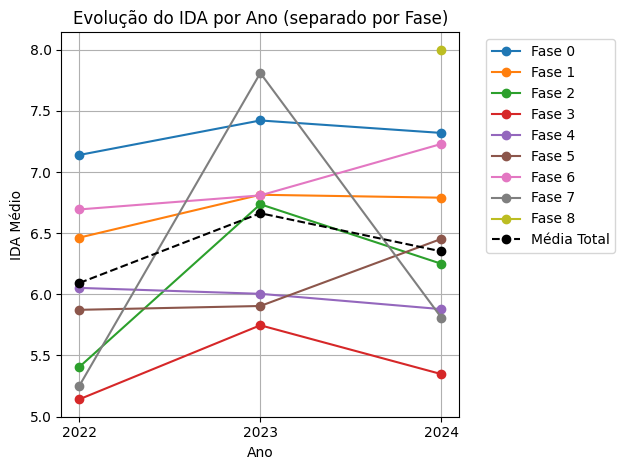

In [29]:
plt.figure()

for fase in sorted(media_fase['FASE'].dropna().unique()):
    subset = media_fase[media_fase['FASE'] == fase]
    plt.plot(subset['ANO'], subset['IDA'], marker='o', label=f'Fase {int(fase)}')
plt.plot(media_ida_ano['ANO'], media_ida_ano['IDA'], marker='o', label='Média Total', linestyle='--', color='black')

plt.title('Evolução do IDA por Ano (separado por Fase)')
plt.xlabel('Ano')
plt.ylabel('IDA Médio')
plt.xticks(sorted(media_fase['ANO'].unique()))


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [30]:
df_p3 = pd.concat([
    df1[['IEG', 'IDA', 'IPV', 'ANO']],
    df2[['IEG', 'IDA', 'IPV', 'ANO']],
    df3[['IEG', 'IDA', 'IPV', 'ANO']]
], ignore_index=True)

# Limpeza
df_p3 = df_p3.dropna(subset=['IEG', 'IDA', 'IPV'])

In [31]:
correlacao_p3 = df_p3[['IEG', 'IDA', 'IPV']].corr()
print(correlacao_p3)

          IEG       IDA       IPV
IEG  1.000000  0.543253  0.558282
IDA  0.543253  1.000000  0.557072
IPV  0.558282  0.557072  1.000000


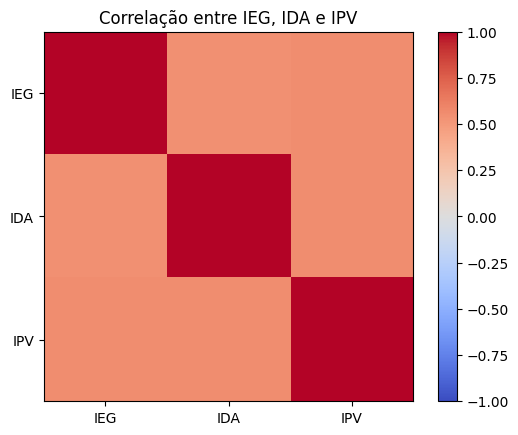

In [32]:
plt.figure()
plt.imshow(correlacao_p3, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(correlacao_p3.columns)), correlacao_p3.columns)
plt.yticks(range(len(correlacao_p3.columns)), correlacao_p3.columns)

plt.title('Correlação entre IEG, IDA e IPV')
plt.show()

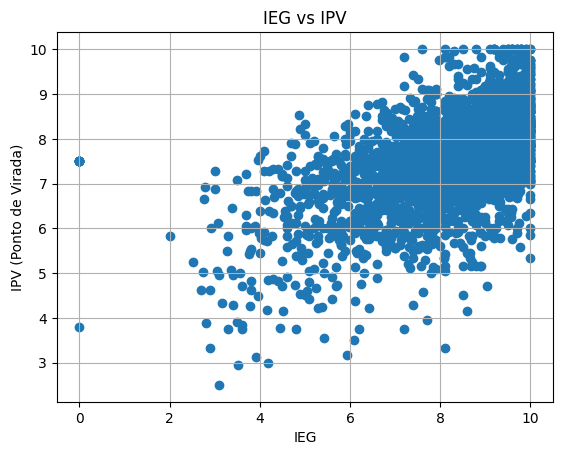

In [33]:
plt.figure()
plt.scatter(df_p3['IEG'], df_p3['IPV'])

plt.xlabel('IEG')
plt.ylabel('IPV (Ponto de Virada)')
plt.title('IEG vs IPV')

plt.grid(True)
plt.show()

In [34]:
df_p3['FAIXA_IEG'] = pd.cut(df_p3['IEG'], bins=3, labels=['Baixo', 'Médio', 'Alto'])

analise = df_p3.groupby('FAIXA_IEG')[['IDA', 'IPV']].mean()
print(analise)

                IDA       IPV
FAIXA_IEG                    
Baixo      2.535119  5.737333
Médio      4.572386  6.459392
Alto       6.724527  7.750129


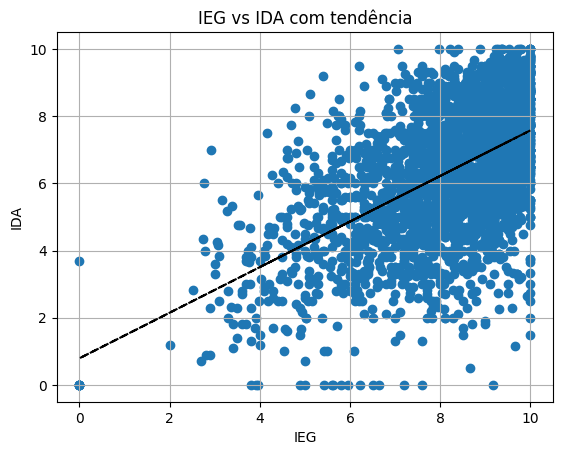

In [35]:
plt.figure()
plt.scatter(df_p3['IEG'], df_p3['IDA'])

# linha de tendência
z = np.polyfit(df_p3['IEG'], df_p3['IDA'], 1)
p = np.poly1d(z)
plt.plot(df_p3['IEG'], p(df_p3['IEG']), color='black', linestyle='--', label='Tendência')

plt.xlabel('IEG')
plt.ylabel('IDA')
plt.title('IEG vs IDA com tendência')

plt.grid(True)
plt.show()

4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [36]:
df_p4 = pd.concat([
    df1[['IAA', 'IDA', 'IEG', 'ANO']],
    df2[['IAA', 'IDA', 'IEG', 'ANO']],
    df3[['IAA', 'IDA', 'IEG', 'ANO']]
], ignore_index=True)

df_p4.isnull().sum()

IAA    165
IDA    178
IEG     76
ANO      0
dtype: int64

In [37]:
df_p4 = df_p4.dropna(subset=['IAA', 'IDA', 'IEG'])

In [38]:
correlacao_p4 = df_p4[['IAA', 'IDA', 'IEG']].corr()
print(correlacao_p4)

          IAA       IDA       IEG
IAA  1.000000  0.115241  0.131324
IDA  0.115241  1.000000  0.543253
IEG  0.131324  0.543253  1.000000


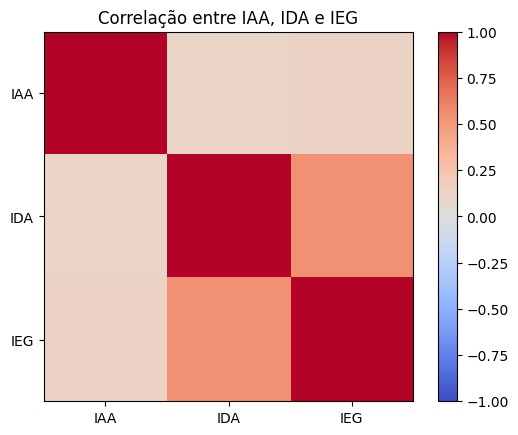

In [39]:
plt.figure()
plt.imshow(correlacao_p4, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(correlacao_p4.columns)), correlacao_p4.columns)
plt.yticks(range(len(correlacao_p4.columns)), correlacao_p4.columns)

plt.title('Correlação entre IAA, IDA e IEG')
plt.show()

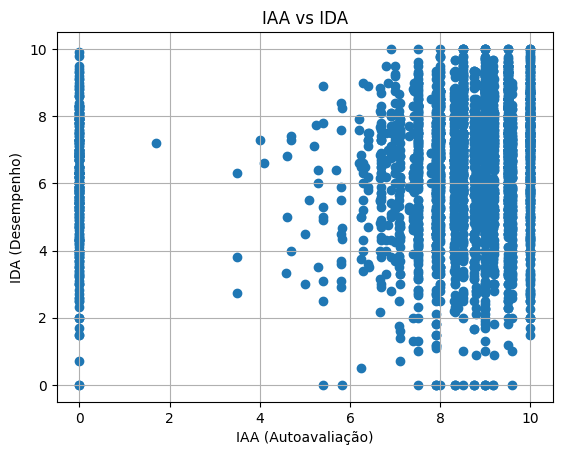

In [40]:
plt.figure()
plt.scatter(df_p4['IAA'], df_p4['IDA'])

plt.xlabel('IAA (Autoavaliação)')
plt.ylabel('IDA (Desempenho)')
plt.title('IAA vs IDA')

plt.grid(True)
plt.show()

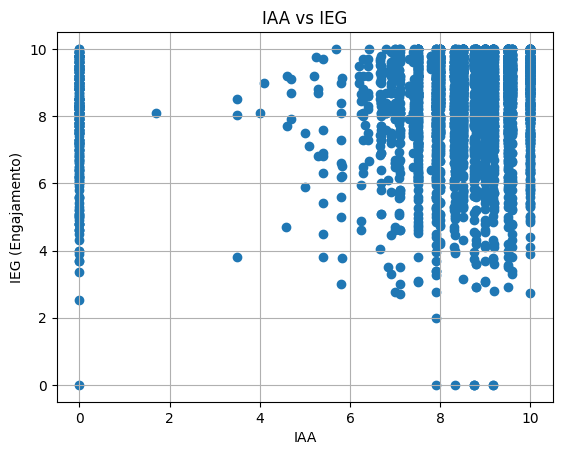

In [41]:
plt.figure()
plt.scatter(df_p4['IAA'], df_p4['IEG'])

plt.xlabel('IAA')
plt.ylabel('IEG (Engajamento)')
plt.title('IAA vs IEG')

plt.grid(True)
plt.show()

In [42]:
df_p4['FAIXA_IAA'] = pd.cut(df_p4['IAA'], bins=3, labels=['Baixo', 'Médio', 'Alto'])

analise = df_p4.groupby('FAIXA_IAA')[['IDA', 'IEG']].mean()
print(analise)

                IDA       IEG
FAIXA_IAA                    
Baixo      5.915583  7.809383
Médio      5.497421  7.660502
Alto       6.449517  8.291073


5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

In [43]:
df_p5 = pd.concat([
    df1[['NOME_ANONIMIZADO', 'IPS', 'IDA', 'IEG', 'ANO']],
    df2[['NOME_ANONIMIZADO', 'IPS', 'IDA', 'IEG', 'ANO']],
    df3[['NOME_ANONIMIZADO', 'IPS', 'IDA', 'IEG', 'ANO']]
], ignore_index=True)

df_p5.isnull().sum()

NOME_ANONIMIZADO      0
IPS                 171
IDA                 178
IEG                  76
ANO                   0
dtype: int64

In [44]:
df_p5 = df_p5.dropna(subset=['IPS', 'IDA', 'IEG'])

In [45]:
df_p5 = df_p5.sort_values(['NOME_ANONIMIZADO', 'ANO'])

df_p5['IPS_ANTERIOR'] = df_p5.groupby('NOME_ANONIMIZADO')['IPS'].shift(1)
df_p5['IDA_POSTERIOR'] = df_p5.groupby('NOME_ANONIMIZADO')['IDA'].shift(-1)
df_p5['IEG_POSTERIOR'] = df_p5.groupby('NOME_ANONIMIZADO')['IEG'].shift(-1)

df_p5.isnull().sum()

NOME_ANONIMIZADO       0
IPS                    0
IDA                    0
IEG                    0
ANO                    0
IPS_ANTERIOR        1586
IDA_POSTERIOR       1586
IEG_POSTERIOR       1586
dtype: int64

In [46]:
corr_ida_p5 = df_p5[['IPS_ANTERIOR', 'IDA_POSTERIOR']].corr()
corr_ieg_p5 = df_p5[['IPS_ANTERIOR', 'IEG_POSTERIOR']].corr()

print(corr_ida_p5)
print(corr_ieg_p5)

               IPS_ANTERIOR  IDA_POSTERIOR
IPS_ANTERIOR       1.000000       0.080505
IDA_POSTERIOR      0.080505       1.000000
               IPS_ANTERIOR  IEG_POSTERIOR
IPS_ANTERIOR       1.000000       0.099916
IEG_POSTERIOR      0.099916       1.000000


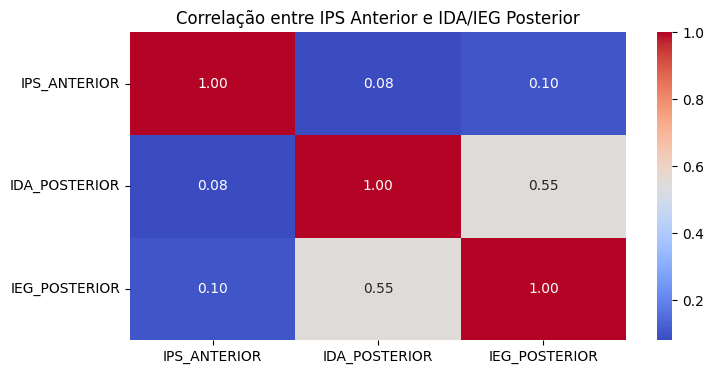

In [47]:
#heatmap da correlação
plt.figure(figsize=(8, 4))
sns.heatmap(df_p5[['IPS_ANTERIOR', 'IDA_POSTERIOR', 'IEG_POSTERIOR']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre IPS Anterior e IDA/IEG Posterior')
plt.show()

In [48]:
df_p5['FAIXA_IPS'] = pd.cut(df_p5['IPS_ANTERIOR'], bins=3, labels=['Baixo', 'Médio', 'Alto'])

analise = df_p5.groupby('FAIXA_IPS')[['IDA_POSTERIOR', 'IEG_POSTERIOR']].mean()
print(analise)

           IDA_POSTERIOR  IEG_POSTERIOR
FAIXA_IPS                              
Baixo           4.839744       7.021531
Médio           6.182857       7.853118
Alto            6.297805       8.038241


6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

In [49]:
df_p6 = pd.concat([
    df2[['IAN', 'IPP']],
    df3[['IAN', 'IPP']]
], ignore_index=True)

df_p6.isnull().sum()

IAN      0
IPP    178
dtype: int64

In [50]:
df_p6 = df_p6.dropna(subset=['IAN', 'IPP'])

In [51]:
df_p6['CATEGORIA_IAN'] = df_p6['IAN'].apply(classificar_ian)

In [52]:
correlacao = df_p6[['IAN', 'IPP']].corr()
print(correlacao)

          IAN       IPP
IAN  1.000000  0.123398
IPP  0.123398  1.000000


In [53]:
analise = df_p6.groupby('CATEGORIA_IAN')['IPP'].mean()
print(analise)

CATEGORIA_IAN
Adequado    7.678196
Moderada    7.459217
Severa      7.010417
Name: IPP, dtype: float64


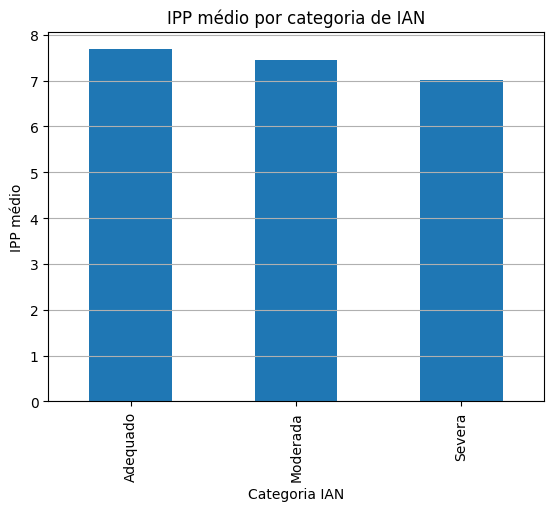

In [54]:
plt.figure()
analise.plot(kind='bar')

plt.title('IPP médio por categoria de IAN')
plt.xlabel('Categoria IAN')
plt.ylabel('IPP médio')

plt.grid(axis='y')
plt.show()

<Figure size 640x480 with 0 Axes>

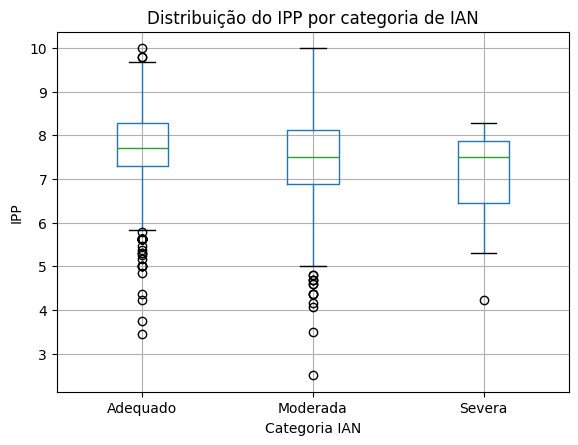

In [55]:
plt.figure()
df_p6.boxplot(column='IPP', by='CATEGORIA_IAN')

plt.title('Distribuição do IPP por categoria de IAN')
plt.suptitle('')
plt.xlabel('Categoria IAN')
plt.ylabel('IPP')

plt.show()

7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

In [56]:
# Bibliotecas
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

df1_p = df1.copy()
df1_p['IPP'] = None

features = ['IPV', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'ANO']
df_pergunta7 = pd.concat([df1_p[features],
                          df2[features],
                          df3[features]], ignore_index=True)

# Preditores por categoria de comportamento
mapeamento = {
    "Acadêmicos":   ["IDA"],
    "Engajamento":  ["IEG"],
    "Emocionais/Psico": ["IPS", "IPP", "IAA"]
}

mapeamentofeatures = {
    "Aprendizagem":   ["IDA"],
    "Engajamento":  ["IEG"],
    "Psicossocial": ["IPS"],
    "Psicopedagogico": ["IPP"],
    "Auto Avaliação": ["IAA"]
}

# Limpeza básica
df_pergunta7 = df_pergunta7.dropna(subset=features).copy()

# Converter as colunas numéricas
for c in df_pergunta7:
    if c in df_pergunta7.columns:
        df_pergunta7[c] = pd.to_numeric(df_pergunta7[c], errors="coerce")

print(len(df_pergunta7))

# Verificando valores nulos
df_pergunta7[features].isnull().sum()


1985


IPV    0
IAA    0
IEG    0
IPS    0
IPP    0
IDA    0
ANO    0
dtype: int64

Anos: [np.int64(2023), np.int64(2024)]


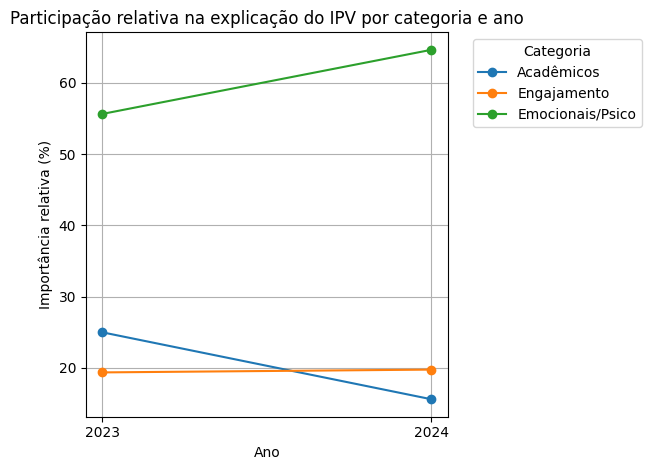

== Importância relativa por categoria e ano (%) ==
    ANO  Acadêmicos  Engajamento  Emocionais/Psico
0  2023   24.995488    19.373919         55.630592
1  2024   15.608520    19.767074         64.624406

== Correlação média absoluta (Spearman) por categoria e ano ==
    ANO  |rho|_Acadêmicos  |rho|_Engajamento  |rho|_Emocionais/Psico
0  2023          0.549725           0.490971                0.246353
1  2024          0.548030           0.550950                0.303327

== Top 3 variáveis (Permutation Importance) por ano ==
Ano 2023:
  IPP: 0.7858
  IDA: 0.4647
  IEG: 0.3602
Ano 2024:
  IPP: 0.8944
  IEG: 0.3197
  IDA: 0.2524


In [57]:
# ============================================
# Importância por ano via RandomForest + Permutation Importance
# ============================================
predictors = ['IAA', 'IEG', 'IPS', 'IPP', 'IDA']
anos = sorted(df_pergunta7['ANO'].unique())

print("Anos:", anos)

linhas = []
top3_por_ano = {}

for ano in anos:
    dfa = df_pergunta7[df_pergunta7['ANO'] == ano].copy()
    if len(dfa) < 30:
        continue

    X = dfa[predictors].values
    y = dfa['IPV'].values

    # Modelo robusto, simples e interpretável via permutation
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X, y)

    perm = permutation_importance(
        rf, X, y,
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )

    importancias = pd.Series(perm.importances_mean, index=predictors)
    importancias[importancias < 0] = 0.0  # zera negativas (ruído)

    # Guarda Top 3 variáveis do ano (para interpretação)
    top3 = importancias.sort_values(ascending=False).head(3)
    top3_por_ano[ano] = top3

    # Agrega por categoria
    row = {'ANO': ano}
    for cat, cols in mapeamento.items():
        row[cat] = importancias.get(cols, pd.Series()).sum()

    # Normaliza para % (participação relativa no ano)
    total = sum(row[c] for c in mapeamento.keys())
    if total > 0:
        for cat in mapeamento.keys():
            row[cat] = (row[cat] / total) * 100.0
    else:
        for cat in mapeamento.keys():
            row[cat] = np.nan

    linhas.append(row)

importancias_cat_ano = pd.DataFrame(linhas).sort_values('ANO').reset_index(drop=True)

# ============================================
# Visualização – evolução da influência por categoria
# ============================================
importancias_cat_ano['ANO'] = importancias_cat_ano['ANO'].astype(str)
plt.figure()
for cat in mapeamento.keys():
    plt.plot(importancias_cat_ano['ANO'], importancias_cat_ano[cat], marker='o', label=cat)

plt.title('Participação relativa na explicação do IPV por categoria e ano')
plt.xlabel('Ano')
plt.ylabel('Importância relativa (%)')
plt.grid(True)
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
#  Correlações de apoio por ano (Spearman)
#    Úteis para interpretar direção/força e consistência.
# ============================================
corr_por_ano = []
for ano in anos:
    dfa = df_pergunta7[df_pergunta7['ANO'] == ano]
    if len(dfa) < 10:
        continue
    corr = dfa[predictors + ['IPV']].corr(method='spearman')['IPV'].drop('IPV')
    linha = {'ANO': ano}
    # agregações por categoria (média do |rho| dentro da categoria)
    for cat, cols in mapeamento.items():
        linha[f'|rho|_{cat}'] = corr[cols].abs().mean()
    corr_por_ano.append(linha)

corr_cat_ano = pd.DataFrame(corr_por_ano).sort_values('ANO')

# Impressão rápida de apoio
print("== Importância relativa por categoria e ano (%) ==")
print(importancias_cat_ano)

print("\n== Correlação média absoluta (Spearman) por categoria e ano ==")
print(corr_cat_ano)

print("\n== Top 3 variáveis (Permutation Importance) por ano ==")
for ano, s in top3_por_ano.items():
    print(f"Ano {ano}:")
    for var, val in s.items():
        print(f"  {var}: {val:.4f}")

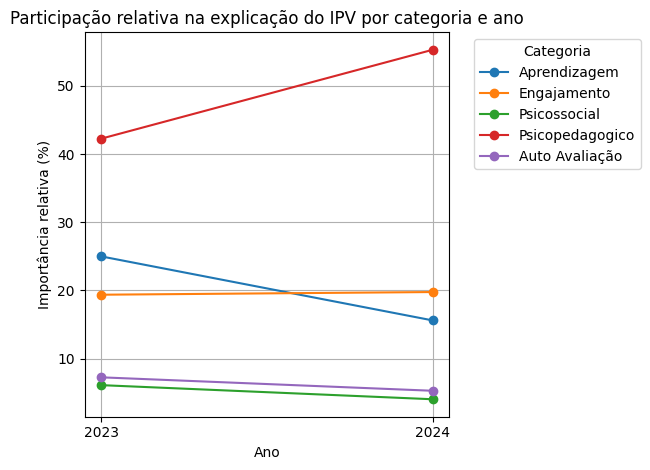

== Importância relativa por categoria e ano (%) ==
    ANO  Aprendizagem  Engajamento  Psicossocial  Psicopedagogico  \
0  2023     24.995488    19.373919      6.109898        42.264606   
1  2024     15.608520    19.767074      4.040234        55.299498   

   Auto Avaliação  
0        7.256088  
1        5.284674  

== Correlação média absoluta (Spearman) por categoria e ano ==
    ANO  |rho|_Aprendizagem  |rho|_Engajamento  |rho|_Psicossocial  \
0  2023            0.549725           0.490971            0.071938   
1  2024            0.548030           0.550950            0.041574   

   |rho|_Psicopedagogico  |rho|_Auto Avaliação  
0               0.511895              0.155225  
1               0.705106              0.163303  

== Top 3 variáveis (Permutation Importance) por ano ==
Ano 2023:
  IPP: 0.7858
  IDA: 0.4647
  IEG: 0.3602
Ano 2024:
  IPP: 0.8944
  IEG: 0.3197
  IDA: 0.2524


In [58]:
# ============================================
# Importância por ano via RandomForest + Permutation Importance
# ============================================
predictors = ['IAA', 'IEG', 'IPS', 'IPP', 'IDA']
anos = sorted(df_pergunta7['ANO'].unique())

linhas = []
top3_por_ano = {}

for ano in anos:
    dfa = df_pergunta7[df_pergunta7['ANO'] == ano].copy()
    if len(dfa) < 30:
        continue

    X = dfa[predictors].values
    y = dfa['IPV'].values

    # Modelo robusto, simples e interpretável via permutation
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X, y)

    perm = permutation_importance(
        rf, X, y,
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )

    importancias = pd.Series(perm.importances_mean, index=predictors)
    importancias[importancias < 0] = 0.0  # zera negativas (ruído)

    # Guarda Top 3 variáveis do ano (para interpretação)
    top3 = importancias.sort_values(ascending=False).head(3)
    top3_por_ano[ano] = top3

    # Agrega por categoria
    row = {'ANO': ano}
    for cat, cols in mapeamentofeatures.items():
        row[cat] = importancias.get(cols, pd.Series()).sum()

    # Normaliza para % (participação relativa no ano)
    total = sum(row[c] for c in mapeamentofeatures.keys())
    if total > 0:
        for cat in mapeamentofeatures.keys():
            row[cat] = (row[cat] / total) * 100.0
    else:
        for cat in mapeamentofeatures.keys():
            row[cat] = np.nan

    linhas.append(row)

importancias_cat_ano2 = pd.DataFrame(linhas).sort_values('ANO').reset_index(drop=True)

# ============================================
# Visualização – evolução da influência por categoria
# ============================================
importancias_cat_ano2['ANO'] = importancias_cat_ano2['ANO'].astype(str)
plt.figure()
for cat in mapeamentofeatures.keys():
    plt.plot(importancias_cat_ano2['ANO'], importancias_cat_ano2[cat], marker='o', label=cat)

plt.title('Participação relativa na explicação do IPV por categoria e ano')
plt.xlabel('Ano')
plt.ylabel('Importância relativa (%)')
plt.grid(True)
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
#  Correlações de apoio por ano (Spearman)
#    Úteis para interpretar direção/força e consistência.
# ============================================
corr_por_ano = []
for ano in anos:
    dfa = df_pergunta7[df_pergunta7['ANO'] == ano]
    if len(dfa) < 10:
        continue
    corr = dfa[predictors + ['IPV']].corr(method='spearman')['IPV'].drop('IPV')
    linha = {'ANO': ano}
    # agregações por categoria (média do |rho| dentro da categoria)
    for cat, cols in mapeamentofeatures.items():
        linha[f'|rho|_{cat}'] = corr[cols].abs().mean()
    corr_por_ano.append(linha)

corr_cat_ano = pd.DataFrame(corr_por_ano).sort_values('ANO')

# Impressão rápida de apoio
print("== Importância relativa por categoria e ano (%) ==")
print(importancias_cat_ano2)

print("\n== Correlação média absoluta (Spearman) por categoria e ano ==")
print(corr_cat_ano)

print("\n== Top 3 variáveis (Permutation Importance) por ano ==")
for ano, s in top3_por_ano.items():
    print(f"Ano {ano}:")
    for var, val in s.items():
        print(f"  {var}: {val:.4f}")

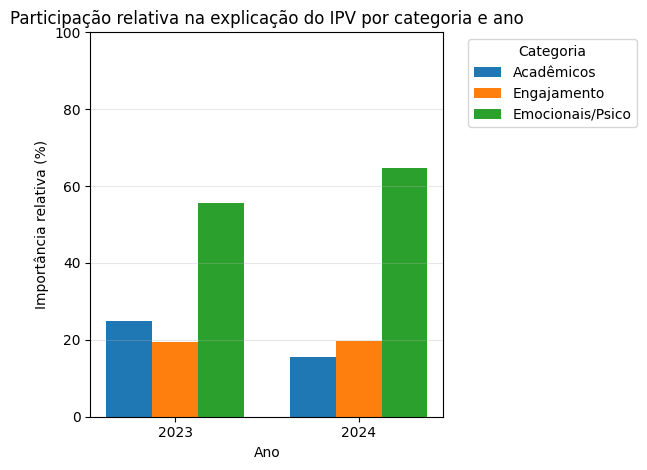

In [59]:
categorias = list(mapeamento.keys())
importancias_cat_ano['ANO'] = importancias_cat_ano['ANO'].astype(str)

anos = importancias_cat_ano['ANO'].tolist()
x = np.arange(len(anos))
largura = 0.25  # ajuste se quiser barras mais largas/estreitas


plt.figure()
for i, cat in enumerate(categorias):
    plt.bar(
        x + (i - (len(categorias)-1)/2) * largura,
        importancias_cat_ano[cat].values,
        width=largura,
        label=cat
    )

plt.title('Participação relativa na explicação do IPV por categoria e ano')
plt.xlabel('Ano')
plt.ylabel('Importância relativa (%)')
plt.xticks(x, anos)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


['Aprendizagem', 'Engajamento', 'Psicossocial', 'Psicopedagogico', 'Auto Avaliação']


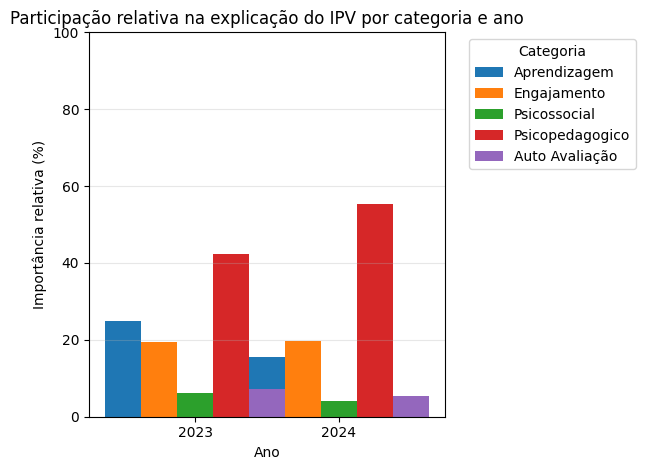

In [60]:
categorias = list(mapeamentofeatures.keys())
print(categorias)
importancias_cat_ano2['ANO'] = importancias_cat_ano2['ANO'].astype(str)

anos = importancias_cat_ano2['ANO'].tolist()
x = np.arange(len(anos))
largura = 0.25  # ajuste se quiser barras mais largas/estreitas


plt.figure()
for i, cat in enumerate(categorias):
    plt.bar(
        x + (i - (len(categorias)-1)/2) * largura,
        importancias_cat_ano2[cat].values,
        width=largura,
        label=cat
    )

plt.title('Participação relativa na explicação do IPV por categoria e ano')
plt.xlabel('Ano')
plt.ylabel('Importância relativa (%)')
plt.xticks(x, anos)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

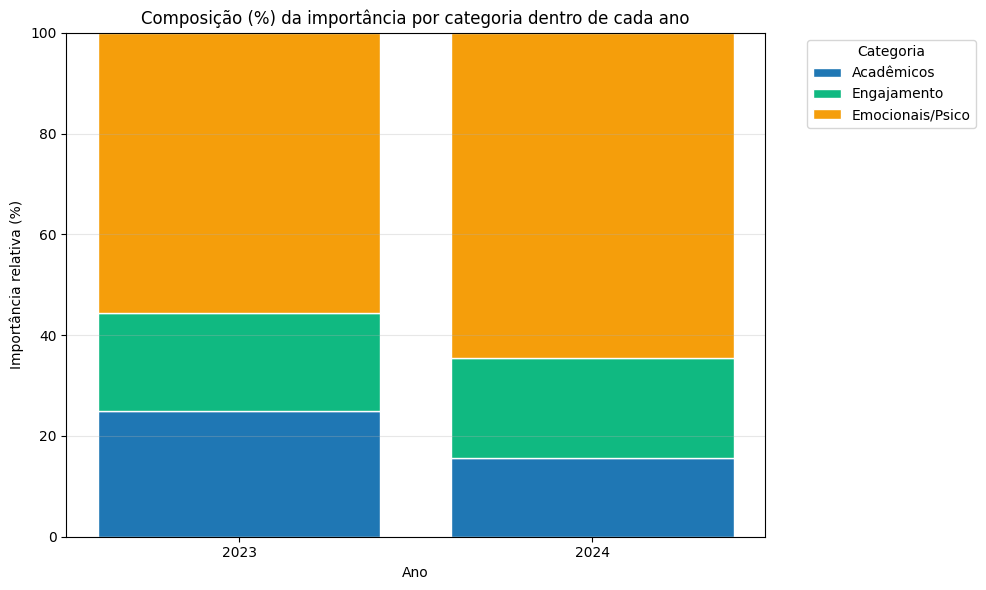

In [61]:
categorias = list(mapeamento.keys())
anos = importancias_cat_ano['ANO'].tolist()

cores = {
    "Academicos": "#3b82f6",       # azul
    "Engajamento": "#10b981",      # verde
    "Emocionais/Psico": "#f59e0b"  # âmbar
}

plt.figure(figsize=(10, 6))
bottom = np.zeros(len(importancias_cat_ano))

for cat in categorias:
    valores = importancias_cat_ano[cat].values
    plt.bar(anos, valores, bottom=bottom, label=cat, color=cores.get(cat, None), edgecolor='white')
    bottom += valores

plt.title('Composição (%) da importância por categoria dentro de cada ano')
plt.xlabel('Ano')
plt.ylabel('Importância relativa (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

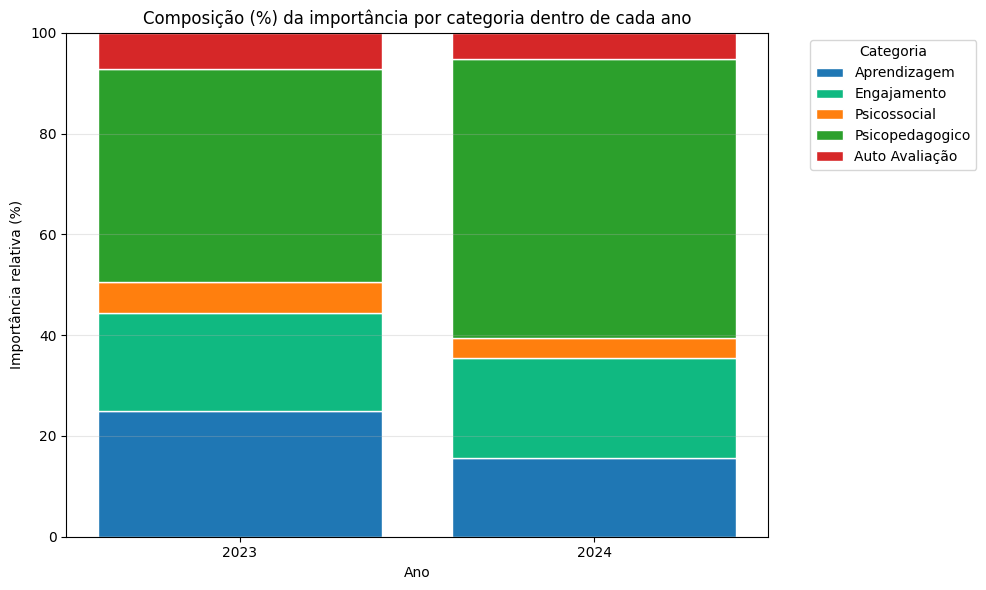

In [62]:
categorias = list(mapeamentofeatures.keys())
anos = importancias_cat_ano2['ANO'].tolist()

cores = {
    "Academicos": "#3b82f6",       # azul
    "Engajamento": "#10b981",      # verde
    "Emocionais/Psico": "#f59e0b"  # âmbar
}

plt.figure(figsize=(10, 6))
bottom = np.zeros(len(importancias_cat_ano2))

for cat in categorias:
    valores = importancias_cat_ano2[cat].values
    plt.bar(anos, valores, bottom=bottom, label=cat, color=cores.get(cat, None), edgecolor='white')
    bottom += valores

plt.title('Composição (%) da importância por categoria dentro de cada ano')
plt.xlabel('Ano')
plt.ylabel('Importância relativa (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

8.⁠ ⁠Multidimensionalidade dos indicadores
Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

In [63]:


df_p8 = pd.concat([
    df2[['IDA', 'IEG', 'IPS', 'IPP', 'INDE_ATUAL']],
    df3[['IDA', 'IEG', 'IPS', 'IPP', 'INDE_ATUAL']]
], ignore_index=True)

df_p8.isnull().sum()

IDA           178
IEG            76
IPS           171
IPP           178
INDE_ATUAL    147
dtype: int64

In [64]:
df_p8 = df_p8.dropna(subset=['IDA', 'IEG', 'IPS', 'IPP', 'INDE_ATUAL'])

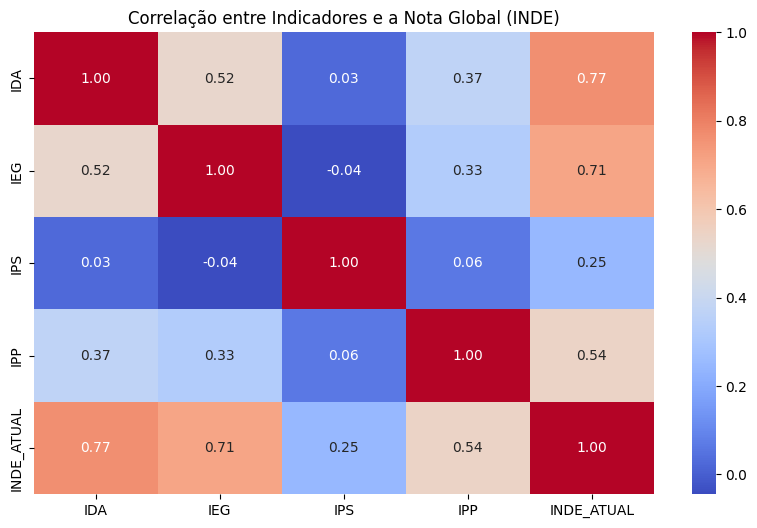

Importância de cada indicador na composição do INDE:
  Indicador  Peso (Impacto no INDE)
1       IEG                0.254913
0       IDA                0.237186
3       IPP                0.226654
2       IPS                0.117792


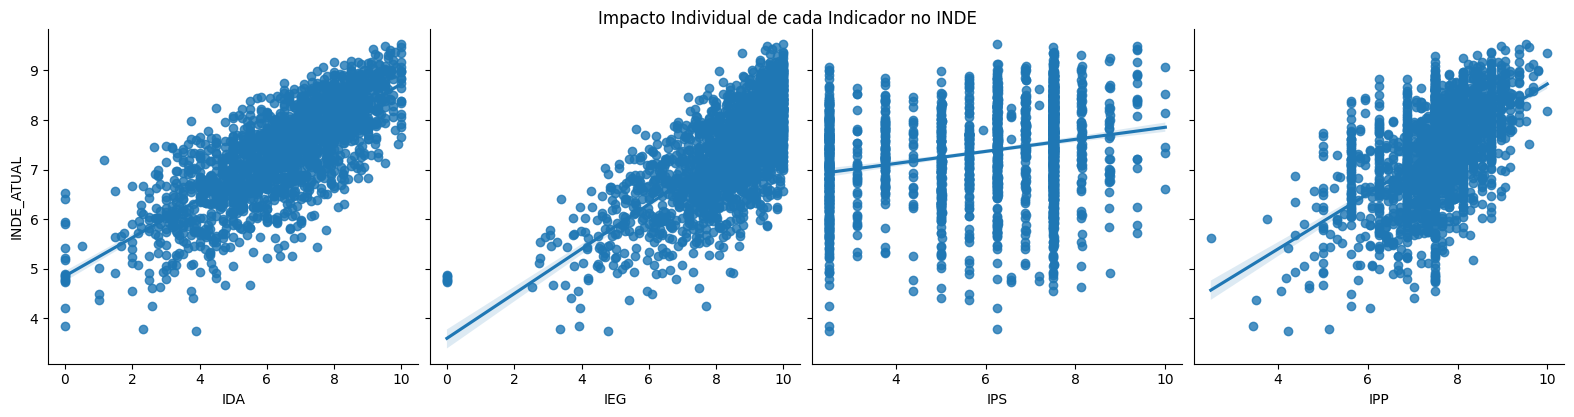

In [65]:
# Convertendo tudo para numérico
for col in ['IDA', 'IEG', 'IPS', 'IPP', 'INDE_ATUAL']:
    df_p8[col] = pd.to_numeric(df_p8[col], errors='coerce')
    
# Correlação de qual indicador isolado mais afeta o INDE
plt.figure(figsize=(10, 6))
sns.heatmap(df_p8.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre Indicadores e a Nota Global (INDE)')
plt.show()

# 3. Verificação de "Peso" (Importância) de cada um
indicadores = ['IDA', 'IEG', 'IPS', 'IPP']

target = 'INDE_ATUAL'

X = df_p8[indicadores]
y = df_p8[target]

modelo = LinearRegression()
modelo.fit(X, y)

# Criando um DataFrame com os coeficientes
importancia = pd.DataFrame({
    'Indicador': indicadores,
    'Peso (Impacto no INDE)': modelo.coef_
}).sort_values(by='Peso (Impacto no INDE)', ascending=False)

print("Importância de cada indicador na composição do INDE:")
print(importancia)

# 4. Visualização da Combinação
sns.pairplot(df_p8, x_vars=indicadores, y_vars=target, kind='reg', height=4)
plt.suptitle('Impacto Individual de cada Indicador no INDE', y=1.02)
plt.show()

In [ ]:
df_p10 = df3.dropna(subset=['INDE 22', 'INDE 23', 'INDE 2024']).copy()

df_long = pd.DataFrame({
    'RA': list(df_p10['RA']) * 3,
    'ANO': [2022]*len(df_p10) + [2023]*len(df_p10) + [2024]*len(df_p10),
    'PEDRA': list(df_p10['PEDRA 22']) + list(df_p10['PEDRA 23']) + list(df_p10['PEDRA 2024']),
    'INDE': list(df_p10['INDE 22']) + list(df_p10['INDE 23']) + list(df_p10['INDE 2024'])
})

print(df_p10.shape)

(434, 52)


In [78]:
df_long['PEDRA'] = df_long['PEDRA'].str.strip().str.title()

mapa_pedras = {
    'Quartzo': 'Quartzo',
    'Agata': 'Ágata',
    'Ágata': 'Ágata',
    'Ametista': 'Ametista',
    'Topazio': 'Topázio',
    'Topázio': 'Topázio'
}

df_long['PEDRA'] = df_long['PEDRA'].map(mapa_pedras)

In [79]:
media_p10 = df_long.groupby(['ANO', 'PEDRA'])['INDE'].mean().reset_index()
pivot = media_p10.pivot(index='ANO', columns='PEDRA', values='INDE')
print(pivot)

PEDRA  Ametista   Quartzo   Topázio     Ágata
ANO                                          
2022   7.552551  5.419001  8.337308  6.654513
2023   7.531259  5.634805  8.372003  6.564748
2024   7.497012  5.359827  8.511356  6.608484


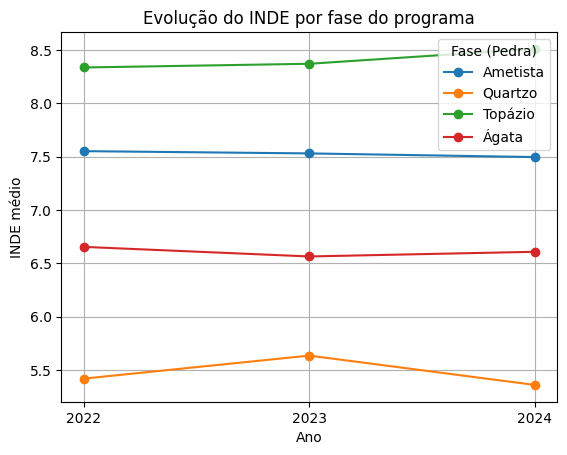

In [80]:
plt.figure()

for pedra in pivot.columns:
    plt.plot(pivot.index, pivot[pedra], marker='o', label=pedra)

plt.xticks([2022, 2023, 2024])
plt.title('Evolução do INDE por fase do programa')
plt.xlabel('Ano')
plt.ylabel('INDE médio')

plt.legend(title='Fase (Pedra)')
plt.grid(True)

plt.show()